In [1]:
import torch
import torch.nn as nn
from tqdm import tqdm

from red import UNet3D
from qsmloader import QSMLoader
from torch.utils.data import DataLoader
from utils import plot_3d_medical_image
import matplotlib.pyplot as plt
from loss import quantile_regression_loss_fn
from scipy import io
from utils import continuous_dipole_kernel
import numpy as np

In [2]:
torch.cuda.init()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load COSMOS data

In [3]:
data = io.loadmat('F:/data/Cosmos_SNR100.mat')
chi_cosmos = data['chi_cosmos'] * data['mask_use']
mask_cosmos = data['mask_use']

data = io.loadmat('F:/data/evaluation_mask.mat')
eval_mask_cosmos = data['evaluation_mask']

In [10]:

def gen_cosmos():
    phase = np.real(np.fft.ifftn(np.fft.fftn(chi_cosmos) * continuous_dipole_kernel(chi_cosmos.shape))) * mask_cosmos

    mag = chi_cosmos - chi_cosmos.min()
    mag = mag / mag.max()
    mag = mag * mask_cosmos

    scale = np.pi / (2 * np.max(np.abs(phase)))
    signal = mag * np.exp(1j * phase * scale)

    snr = np.random.randint(95, 105, (1,))

    signal = signal + ((1. / snr) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)))

    phase = np.angle(signal).astype(np.float32) / scale
    phase = phase * mask_cosmos
    phase[80, 80, 80] = 2

    p = torch.Tensor(phase.copy()).unsqueeze(0).unsqueeze(0)
    return p

In [11]:
def eval_cosmos(recon):
    metrics = {}
    metrics['rmse'] = 100 * np.linalg.norm(recon.ravel() - chi_cosmos.ravel()) / np.linalg.norm(chi_cosmos.ravel())
    for i in range(12):
        sub_mask = eval_mask_cosmos == i
        pred = recon[sub_mask]
        gt = chi_cosmos[sub_mask]
        metrics[f'rmse_zona_{i}'] = 100 * np.linalg.norm(gt - pred) / np.linalg.norm(gt)
        metrics[f'mean_zona_{i}'] = np.mean(pred)
        metrics[f'std_zona_{i}'] = np.std(pred)
    return metrics

# Load Model

In [6]:
model = UNet3D(in_channels=1, out_channels=3)
model = model.to(device)
# model.load_state_dict(torch.load('./saved/model_epoch_48.pth', weights_only=False))
model.eval()

UNet3D(
  (enc1): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (enc2): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): L

In [12]:
p = gen_cosmos()
p2 = gen_cosmos()

In [13]:
rmse = []
rmse2 = []
for i in tqdm(range(1, 13)):

    if i < 11:
        model.load_state_dict(torch.load(f'./saved/checkpoint_epoch_{i}.pth', weights_only=False)['model'])
    elif i == 11:
        model.load_state_dict(torch.load(f'./saved/checkpoint_epoch_8_respaldo.pth', weights_only=False)['model'])
    elif i == 12:
        model.load_state_dict(torch.load(f'./saved/checkpoint_epoch_8_respaldo2.pth', weights_only=False)['model'])
    # model = model.to(device)
    model.eval()
    with torch.inference_mode():
        out = model((p).to(device)).cpu() * mask_cosmos
    gt = chi_cosmos * 1.
    pred = out[0, 1].numpy() * mask_cosmos
    m = mask_cosmos == 1
    rmse.append(100 * np.linalg.norm(pred.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))

    with torch.inference_mode():
        out = model((p2).to(device)).cpu() * mask_cosmos
    gt = chi_cosmos * 1.
    pred = out[0, 1].numpy() * mask_cosmos
    m = mask_cosmos == 1
    rmse2.append(100 * np.linalg.norm(pred.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))

100%|██████████| 12/12 [00:14<00:00,  1.20s/it]


0 0 0


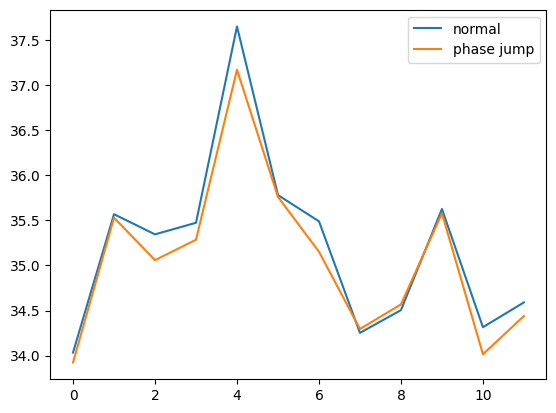

In [14]:
print((np.argmin(rmse)), (np.argmin(rmse2)), np.argmin([rmse[i] + rmse2[i] for i in range(len(rmse))]))
plt.figure()
plt.plot(rmse, label='normal')
plt.plot(rmse2, label='phase jump')
plt.legend()
plt.show()

In [ ]:
rmse[7], rmse[-1]

In [15]:
model = UNet3D(in_channels=1, out_channels=3)
model = model.to(device)
model.load_state_dict(torch.load('./saved/checkpoint_epoch_1_respaldo.pth', weights_only=False)['model'])
model.eval()

UNet3D(
  (enc1): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (enc2): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): L

# Eval model

In [16]:
def eval_model(model_in, p, mask):
    model_in.eval()
    with torch.inference_mode():
        out = model_in((p).to(device)).cpu() * mask

    output = out * 1
    lam = 1.09375
    output[:, 0, :, :, :] = torch.minimum(output[:, 0, :, :, :], output[:, 1, :, :, :])
    output[:, 2, :, :, :] = torch.maximum(output[:, 2, :, :, :], output[:, 1, :, :, :])
    upper_edge = lam * (output[:, 2, :, :, :] - output[:, 1, :, :, :]) + output[:, 1, :, :, :]
    prediction = output[:, 1, :, :, :]
    lower_edge = output[:, 1, :, :, :] - lam * (output[:, 1, :, :, :] - output[:, 0, :, :, :])

    upper_edge = upper_edge[0].numpy()
    prediction = prediction[0].numpy()
    lower_edge = lower_edge[0].numpy()
    return upper_edge, prediction, lower_edge

In [33]:
p = gen_cosmos()

In [34]:
upper_edge, prediction, lower_edge = eval_model(model, p, mask_cosmos)

In [35]:
eval_cosmos(prediction)

{'rmse': 33.917824403826046,
 'rmse_zona_0': 34.07614443749187,
 'mean_zona_0': 0.00037924788,
 'std_zona_0': 0.012252315,
 'rmse_zona_1': 12.341046260189508,
 'mean_zona_1': 0.05943418,
 'std_zona_1': 0.006893561,
 'rmse_zona_2': 12.308805255745659,
 'mean_zona_2': 0.07682089,
 'std_zona_2': 0.01090606,
 'rmse_zona_3': 7.801684576720756,
 'mean_zona_3': 0.17708208,
 'std_zona_3': 0.022928322,
 'rmse_zona_4': 10.00670043758213,
 'mean_zona_4': 0.09262348,
 'std_zona_4': 0.013662808,
 'rmse_zona_5': 9.778866428964918,
 'mean_zona_5': 0.16235203,
 'std_zona_5': 0.01668541,
 'rmse_zona_6': 9.020290700003322,
 'mean_zona_6': 0.11042447,
 'std_zona_6': 0.011414394,
 'rmse_zona_7': 24.348039195484738,
 'mean_zona_7': -0.018144978,
 'std_zona_7': 0.002731129,
 'rmse_zona_8': 22.92293908852605,
 'mean_zona_8': -0.017252633,
 'std_zona_8': 0.002001331,
 'rmse_zona_9': 16.779544793917452,
 'mean_zona_9': -0.04097787,
 'std_zona_9': 0.00884101,
 'rmse_zona_10': 31.11258335655984,
 'mean_zona_10':

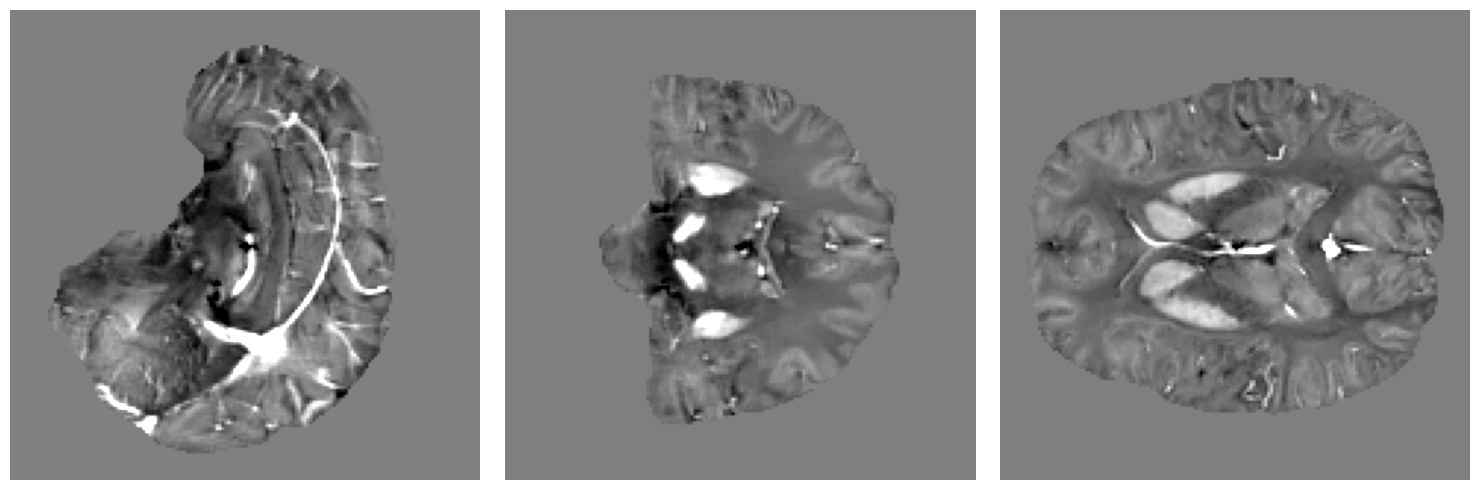

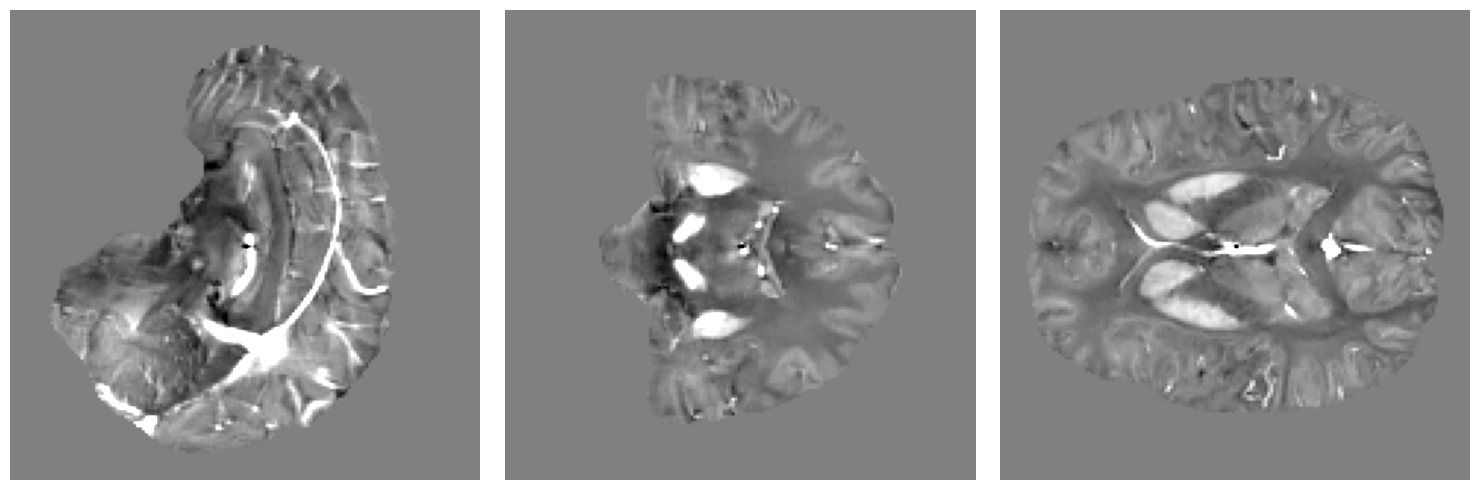

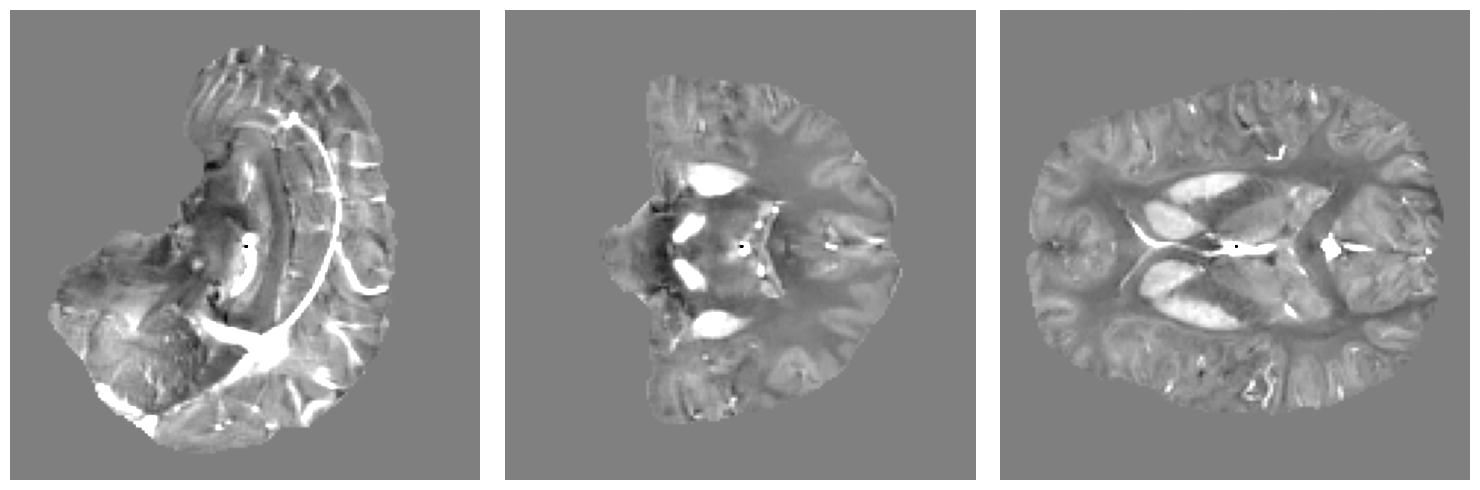

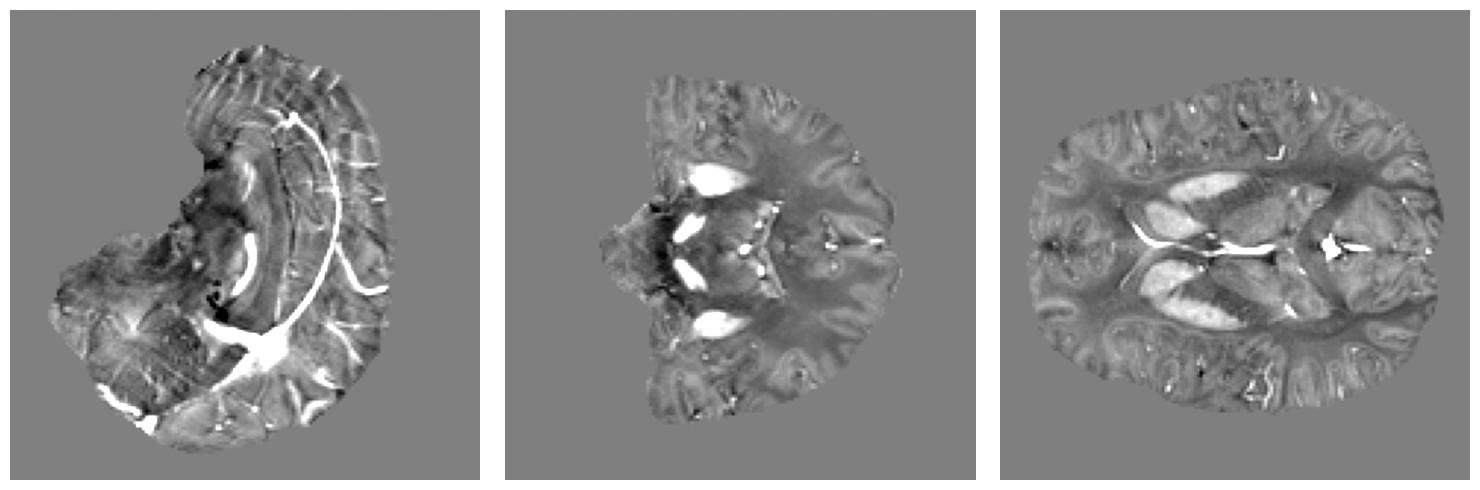

In [20]:
plot_3d_medical_image(lower_edge * mask_cosmos, rango=(-0.1, 0.1))
plot_3d_medical_image(prediction * mask_cosmos, rango=(-0.1, 0.1))
plot_3d_medical_image(upper_edge * mask_cosmos, rango=(-0.1, 0.1))
plot_3d_medical_image(chi_cosmos * mask_cosmos, rango=(-0.1, 0.1))

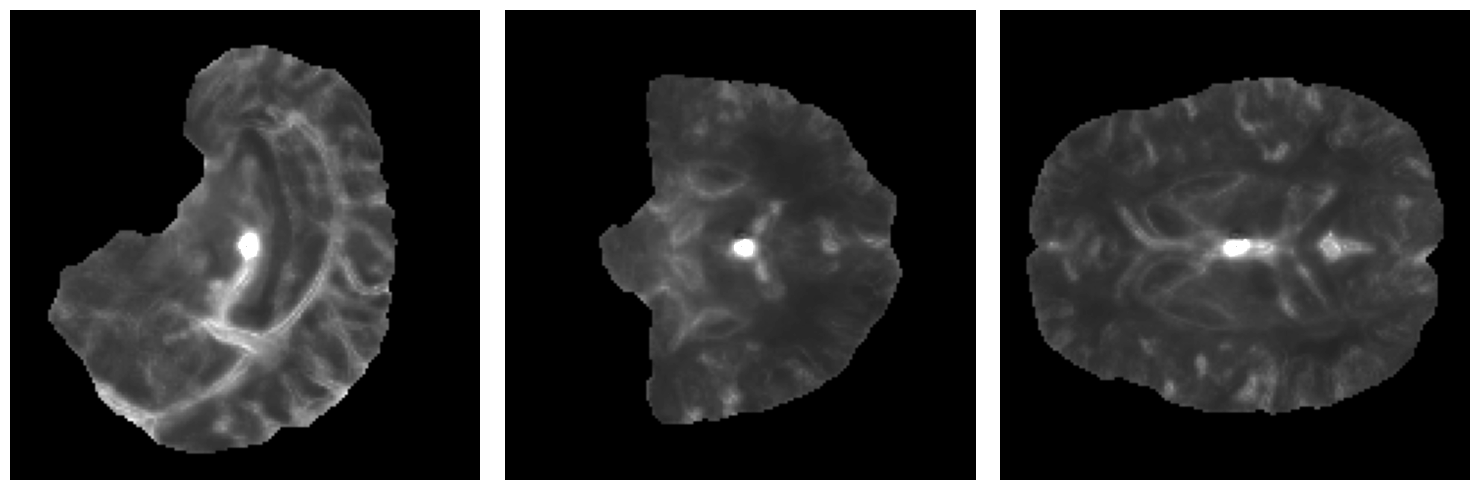

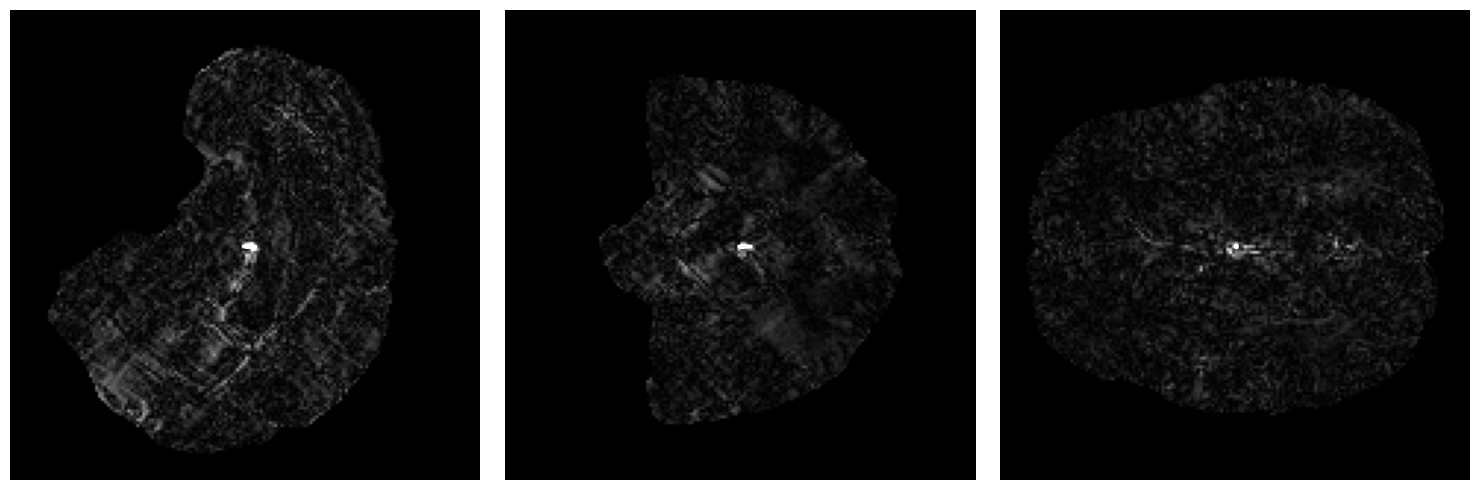

In [21]:
plot_3d_medical_image(a := (upper_edge - lower_edge) * mask_cosmos, rango=(0, 0.1))
plot_3d_medical_image(np.abs(chi_cosmos - prediction) * mask_cosmos, rango=(0, 0.1))


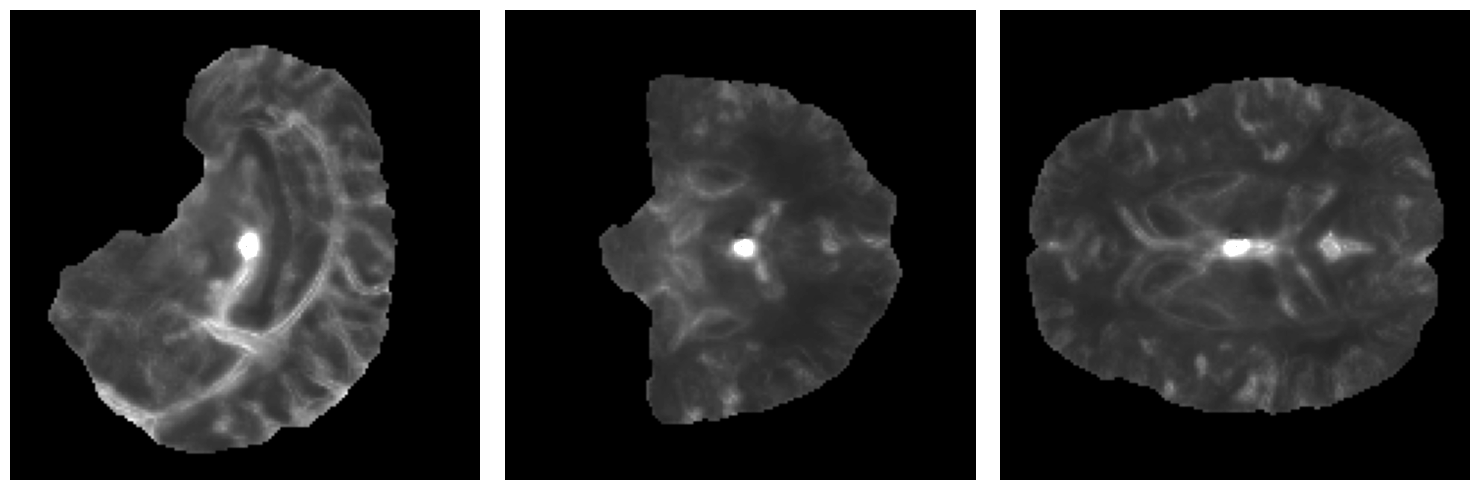

In [32]:
plot_3d_medical_image(np.abs(a), rango=(0, 0.1))

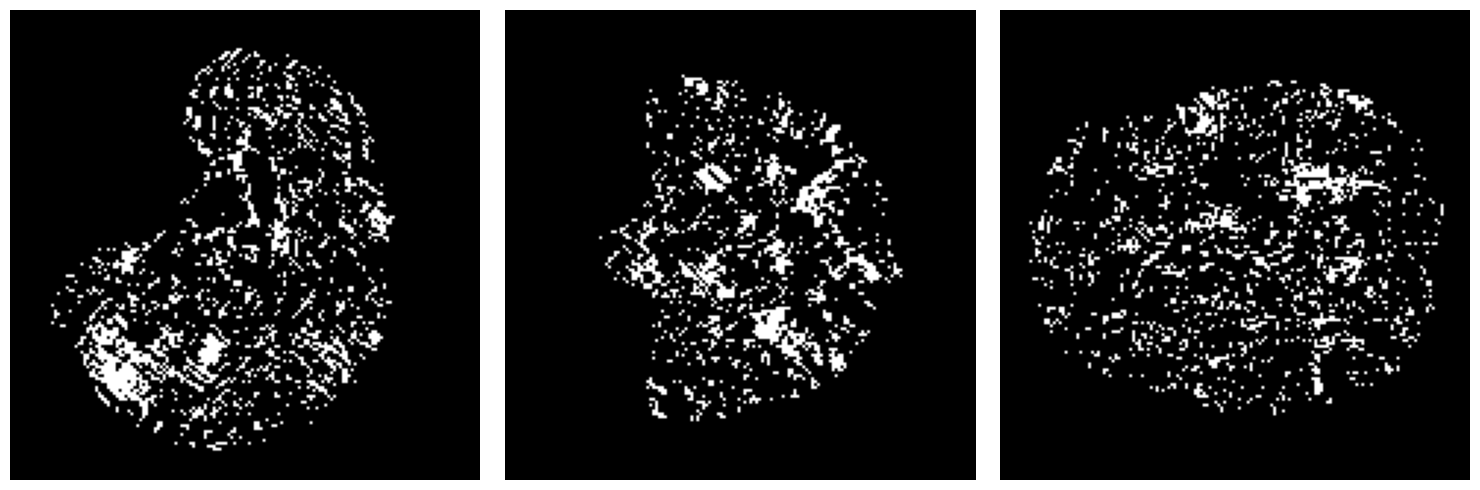

In [38]:
factor = (chi_cosmos < lower_edge) | (upper_edge < chi_cosmos)
plot_3d_medical_image(factor)

In [39]:
factor.shape, mask_cosmos.shape

((160, 160, 160), (160, 160, 160))

In [40]:
np.mean(factor[mask_cosmos == 1])

0.1808521008997505

In [37]:
io.savemat('out.mat',
           {
               'upper_edge': upper_edge,
               'prediction': prediction,
               'lower_edge': lower_edge,
               'p': p,
               'mask_cosmos': mask_cosmos,
               'chi_cosmos': chi_cosmos,
           }
           )

In [41]:
prediction.shape

(160, 160, 160)

In [42]:
phaseL = np.real(np.fft.ifftn(np.fft.fftn(lower_edge) * continuous_dipole_kernel(lower_edge.shape))) * mask_cosmos
phaseU = np.real(np.fft.ifftn(np.fft.fftn(upper_edge) * continuous_dipole_kernel(upper_edge.shape))) * mask_cosmos
phase = np.real(np.fft.ifftn(np.fft.fftn(chi_cosmos) * continuous_dipole_kernel(chi_cosmos.shape))) * mask_cosmos


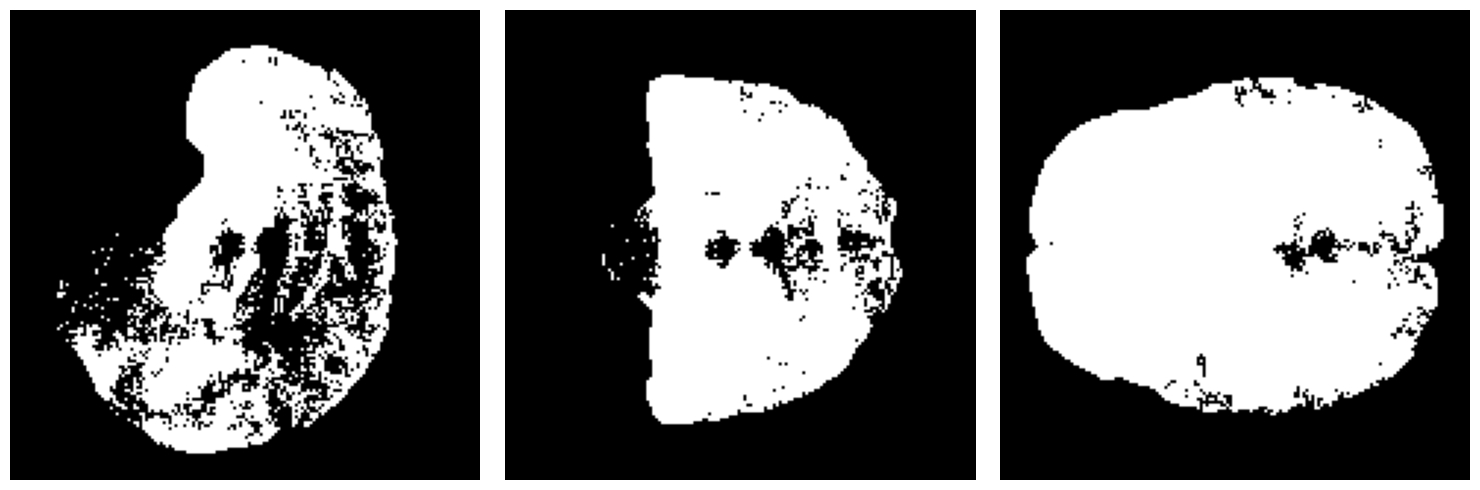

In [43]:
factor = (phase < phaseL) | (phaseU < phase)
plot_3d_medical_image(factor)

In [44]:
np.mean(factor[mask_cosmos == 1])

0.8822343464944653